In [1]:
from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from pathlib import Path

import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "font.family":       "sans-serif",
    "font.sans-serif":   "Arial",
    "font.size":         32,
    "axes.titlesize":    22,
    "axes.labelsize":    22,
    "axes.linewidth":   2.5,
    "xtick.labelsize":   20,
    "ytick.labelsize":   20,
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    "legend.frameon":    False,
    "legend.fontsize":   22,
    "figure.constrained_layout.use": True,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

# ── Palettes ───────────────────────────────────────────────────────────────
CONDITION_PALETTE = {"pre_ttx": "#1d0505", "post_ttx": "#d73939"}
CONDITION_ORDER   = ["pre_ttx", "post_ttx"]
UNIT_PALETTE      = {"83b": "#4477AA", "85b": "#228833", "116b": "#EE6677"}

DECODED_DATA_PATH = Path(r"D:\common_datasets\nrem_sc")
UNITS = ["83b", "85b", "116b"]

# Output directory
FIG_OUT = INTERIM_DATA_PATH / "all_units"
FIG_OUT.mkdir(parents=True, exist_ok=True)

### Sweep Extraction

In [2]:
def extract_sweeps(tdf, label='continuous', min_gap_ms=50):
    """Detect continuous sweep epochs and compute per-sweep metrics."""
    epochs = tdf[tdf['state'] == label].find_support(min_gap=min_gap_ms, time_units='ms')

    if len(epochs) == 0:
        return pd.DataFrame()

    all_data = tdf.restrict(epochs)
    pos = all_data['position'].values
    times = all_data.times('s')

    starts = epochs['start']
    epoch_idx = np.searchsorted(starts, times, side='right') - 1

    split_at = np.flatnonzero(np.diff(epoch_idx)) + 1
    pos_chunks = np.split(pos, split_at)
    time_chunks = np.split(times, split_at)

    durations = np.empty(len(pos_chunks))
    net_disp  = np.empty(len(pos_chunks))
    path_len  = np.empty(len(pos_chunks))
    integral  = np.empty(len(pos_chunks))
    n_samples = np.empty(len(pos_chunks), dtype=int)

    for i, (p, t) in enumerate(zip(pos_chunks, time_chunks)):
        uw = np.unwrap(p, period=360)
        durations[i] = t[-1] - t[0]
        net_disp[i]  = np.diff(uw).sum()
        path_len[i]  = np.abs(np.diff(uw)).sum()
        integral[i]  = np.sum(p - p[0])
        n_samples[i] = len(p)

    mask = n_samples >= 2
    return pd.DataFrame({
        'duration': durations[mask],
        'net_displacement': net_disp[mask],
        'path_length': path_len[mask],
        'integral': integral[mask],
        'n_samples': n_samples[mask],
    })

### Load Data and Extract Sweeps for All Units

In [3]:
threshold = 0.5
all_sweeps = []

for unit in UNITS:
    print(f"Processing {unit}...")
    sleep_states = nap.load_file(PROCESSED_DATA_PATH / unit / "sleep.npz")
    session = nap.load_file(PROCESSED_DATA_PATH / unit / "sessions_labeled.npz")

    tdf = nap.load_file(DECODED_DATA_PATH / unit / "states_combined.npz").as_dataframe()
    tdf['position'] = nap.load_file(DECODED_DATA_PATH / unit / "position_combined.npz").as_series()

    # Split pre/post TTX
    tdf['condition'] = 'pre_ttx'
    ttx_start = session[session['label'] == 'ttx']['start'].item()
    tdf.loc[tdf.index > ttx_start, 'condition'] = 'post_ttx'

    for condition in ['pre_ttx', 'post_ttx']:
        data = tdf[tdf['condition'] == condition].copy(deep=True)

        # State labels from decoded probabilities
        labels = data[['continuous', 'fragmented', 'stationary']]
        data['state'] = np.where(
            labels.max(axis=1) > threshold,
            labels.idxmax(axis=1),
            'mixture',
        )

        # Assign sleep state from scored epochs
        data['sleep_state'] = 'unknown'
        for ep in sleep_states:
            start, end = ep['start'].item(), ep['end'].item()
            if start > data.index[-1]:
                break
            valid = (data.index > start) & (data.index < end)
            data.loc[valid, 'sleep_state'] = ep['state'].item()

        data = nap.TsdFrame(data)
        sweeps = extract_sweeps(
            data[data['sleep_state'] == 'nrem'],
            label='continuous', min_gap_ms=50,
        )
        sweeps['condition'] = condition
        sweeps['sleep_state'] = 'nrem'
        sweeps['unit'] = unit
        all_sweeps.append(sweeps)

sweeps = pd.concat(all_sweeps, ignore_index=True)
sweeps['velocity'] = sweeps['net_displacement'] / sweeps['duration']
sweeps['quartile'] = pd.qcut(sweeps['duration'], 4, labels=False)

print(f"Total sweeps: {len(sweeps)}")
sweeps.head()

Processing 83b...
Processing 85b...
Processing 116b...
Total sweeps: 75384


,duration,net_displacement,path_length,integral,n_samples,condition,sleep_state,unit,velocity,quartile
0,0.215,15.999797,19.999746,2312.970643,216,pre_ttx,nrem,83b,74.417660,2
1,0.827,22.999708,86.998896,-5627.928567,828,pre_ttx,nrem,83b,27.811013,3
2,0.192,-9.999873,15.999797,-1107.985937,193,pre_ttx,nrem,83b,-52.082672,2
3,0.210,-10.999860,10.999860,-1398.982243,211,pre_ttx,nrem,83b,-52.380288,2
4,0.234,-51.999340,51.999340,-3380.957087,235,pre_ttx,nrem,83b,-222.219402,2


### Sweep Statistics per Unit

In [4]:
# Per-unit duration stats (used for quartile annotations)
unit_stats = {}
for unit in UNITS:
    unit_stats[unit] = sweeps[sweeps['unit'] == unit]['duration'].describe()

all_stats = sweeps['duration'].describe()

# Summary table
summary = sweeps.groupby(['unit', 'condition'])[['duration', 'velocity', 'net_displacement']].describe()
summary

duration                                                  \
                  count      mean       std    min    25%    50%    75%   
unit condition                                                            
116b post_ttx   32500.0  0.159984  0.136111  0.001  0.060  0.125  0.223   
     pre_ttx     4838.0  0.192529  0.157300  0.001  0.077  0.160  0.261   
83b  post_ttx    9641.0  0.240085  0.189469  0.001  0.099  0.199  0.328   
     pre_ttx    13688.0  0.245692  0.206348  0.001  0.095  0.198  0.333   
85b  post_ttx    8062.0  0.202128  0.168455  0.001  0.078  0.161  0.277   
     pre_ttx     6655.0  0.211588  0.171572  0.001  0.087  0.171  0.287   

                      velocity             ...                           \
                  max    count       mean  ...        75%           max   
unit condition                             ...                            
116b post_ttx   1.780  32500.0   1.644221  ...  62.807458   4090.857167   
     pre_ttx    1.476   4838.0  -2.688388  ...  63.471901   2499.968269   
83b  post_ttx   2.120   9641.0   5.549806  ...  60.605291   4281.195661   
     pre_ttx    1.989  13688.0   2.408943  ...  69.766556  16124.795340   
85b  post_ttx   1.737   8062.0  -3.579479  ...  64.773333  14545.685317   
     pre_ttx    1.448   6655.0 -14.140881  ...  66.250660   7142.766482   

               net_displacement                                              \
                          count      mean        std         min        25%   
unit condition                                                                
116b post_ttx           32500.0 -0.019062  28.300464 -354.000076  -5.999924   
     pre_ttx             4838.0  0.556834  28.456018 -277.001053 -10.004442   
83b  post_ttx            9641.0  2.376651  38.814570 -409.999365  -6.999911   
     pre_ttx            13688.0  0.715680  43.958206 -725.999924 -11.999848   
85b  post_ttx            8062.0 -0.676162  38.803828 -519.002551 -12.004417   
     pre_ttx             6655.0 -2.468266  43.694002 -396.999530 -16.999784   

                                            
                50%        75%         max  
unit condition                              
116b post_ttx   0.0   6.999911  514.002615  
     pre_ttx    0.0   9.999873  189.002170  
83b  post_ttx   0.0  10.999860  497.998248  
     pre_ttx    0.0  14.000965  367.999898  
85b  post_ttx   0.0  10.999860  317.000546  
     pre_ttx    0.0  11.999848  428.003706  

[6 rows x 24 columns]

In [5]:
all_stats

count    75384.000000
mean         0.196942
std          0.169737
min          0.001000
25%          0.074000
50%          0.155000
75%          0.269000
max          2.120000
Name: duration, dtype: float64

### Sweep Duration Distributions

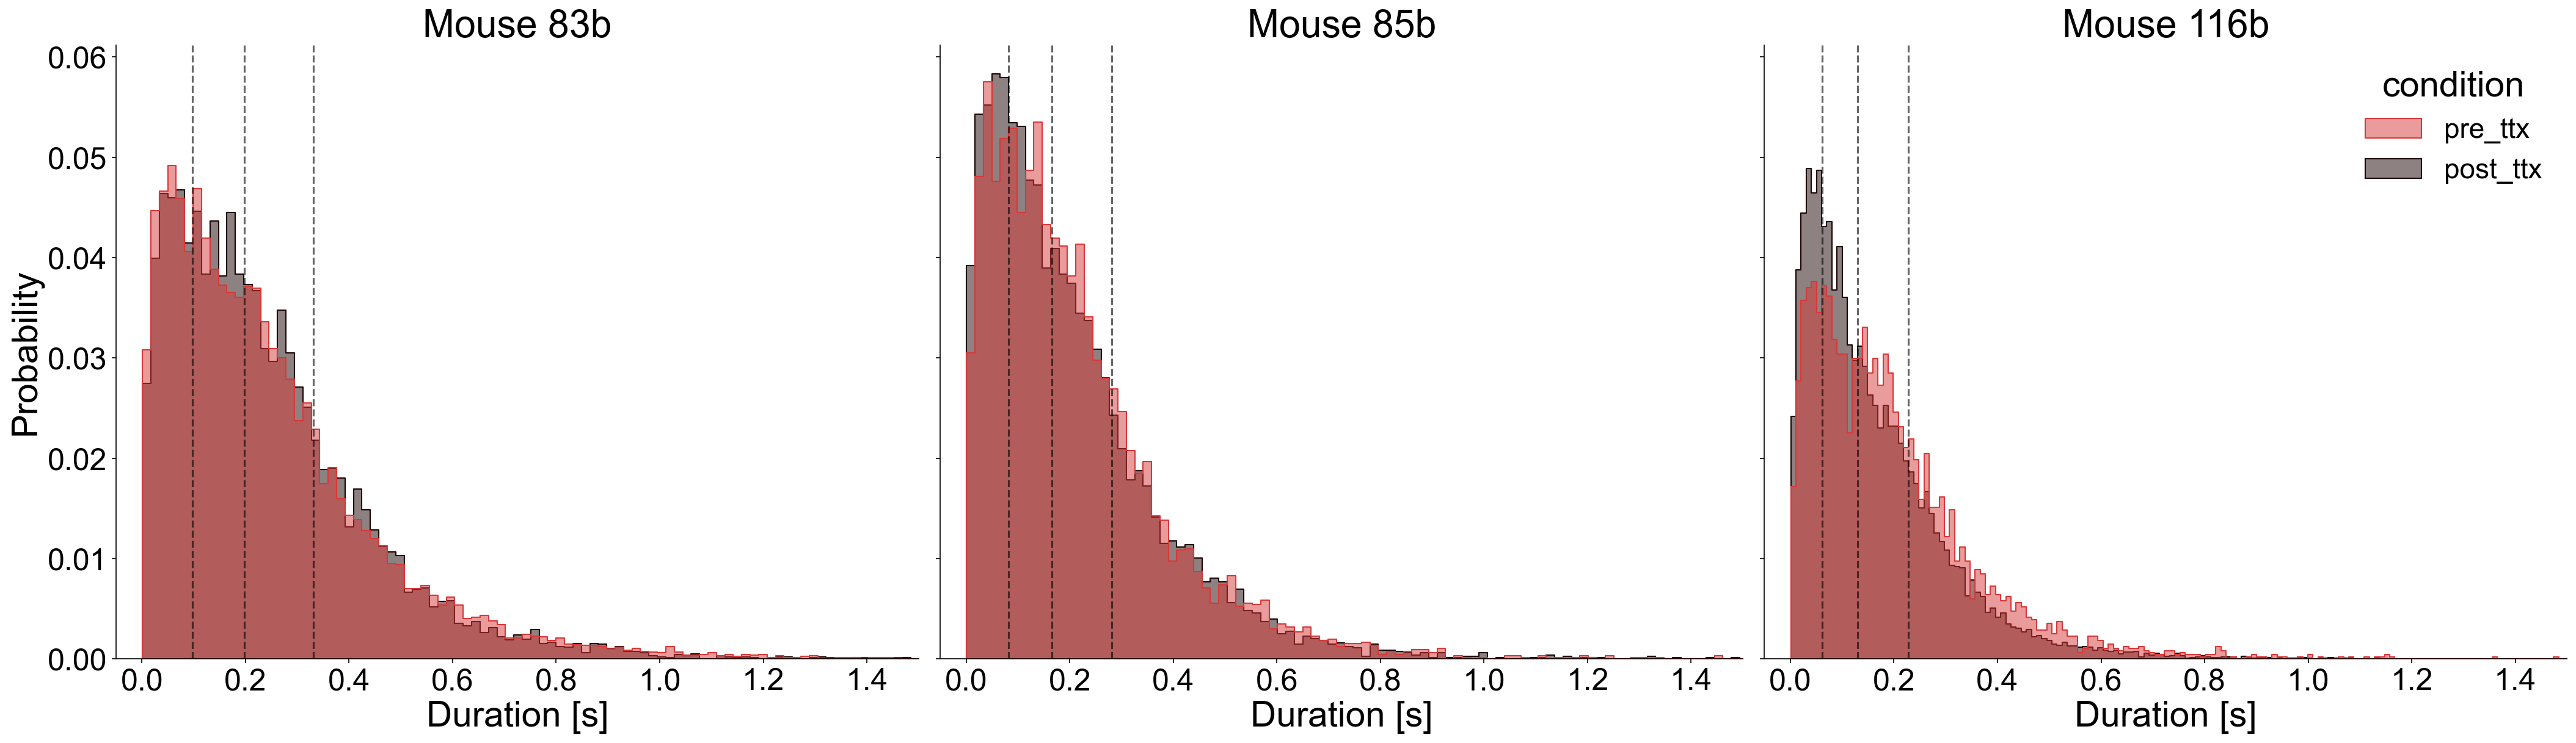

In [20]:
palette = [CONDITION_PALETTE["post_ttx"], CONDITION_PALETTE["pre_ttx"]]
hist_kw = dict(element='step', stat='probability', common_norm=False,
               fill=True, alpha=0.5, palette=palette)

fig, axes = plt.subplots(1, 3, figsize=(28, 8), sharey=True)

for i, unit in enumerate(UNITS):
    udf = sweeps[sweeps['unit'] == unit]
    st = unit_stats[unit]

    sns.histplot(data=udf, x='duration', hue='condition', **hist_kw,
                 ax=axes[i], legend=(i == 2))
    axes[i].set_xlim(-0.05, 1.5)
    axes[i].set_title(f'Mouse {unit}')

    # Quartile reference lines
    for x in [st['25%'], st['50%'], st['75%']]:
        axes[i].axvline(x=x, linewidth=1.5, linestyle='--', color='black', alpha=0.6)

    if i == 0:
        axes[i].set_ylabel('Probability')
    else:
        axes[i].set_ylabel('')
    axes[i].set_xlabel('Duration [s]')

ax.spines['left'].set_linewidth(2.5)
ax.spines['bottom'].set_linewidth(2.5)

# fig.savefig(FIG_OUT / 'nrem_sweep_durations_per_units.pdf', format='pdf', dpi=1200)
# fig.savefig(FIG_OUT / 'nrem_sweep_durations_per_units.png', format='png', dpi=300)
plt.show()

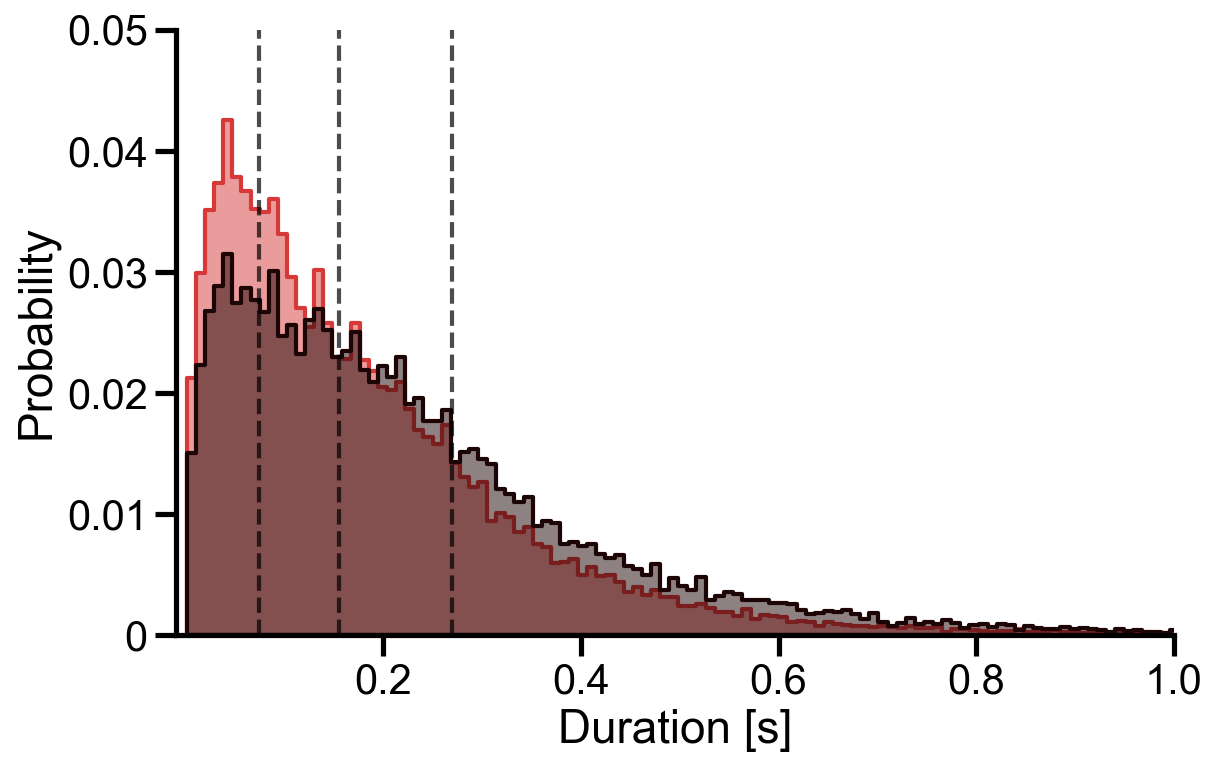

In [213]:
palette = [CONDITION_PALETTE["pre_ttx"], CONDITION_PALETTE["post_ttx"]]
hist_kw = dict(element='step', stat='probability', common_norm=False,
               fill=True, alpha=0.5, palette=palette, linewidth=2.)

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(data=sweeps, x='duration', hue='condition', **hist_kw,
                ax=ax, legend=False)

ax.set_xlim(-0.01, 1.)
ax.set_ylim(0, 0.05)
ax.set_yticks([0, 0.01, 0.02, 0.03, 0.04, 0.05], labels=['0', '0.01', '0.02', '0.03', '0.04', '0.05'])
ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0], labels=['0.2', '0.4', '0.6', '0.8', '1.0'])
ax.tick_params(axis='both', which='major', labelsize=22, width=2.5, length=10)

# # Quartile reference lines
for x in [all_stats['25%'], all_stats['50%'], all_stats['75%']]:
    ax.axvline(x=x, linewidth=2., linestyle='--', color='black', alpha=0.7)

ax.set_ylabel('Probability', fontsize=22)
ax.set_xlabel('Duration [s]', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20, width=2.5, length=10)

fig.savefig(FIG_OUT / 'nrem_sweep_durations_all_units.pdf', format='pdf', dpi=1200)
fig.savefig(FIG_OUT / 'nrem_sweep_durations_all_units.png', format='png', dpi=300)
plt.show()

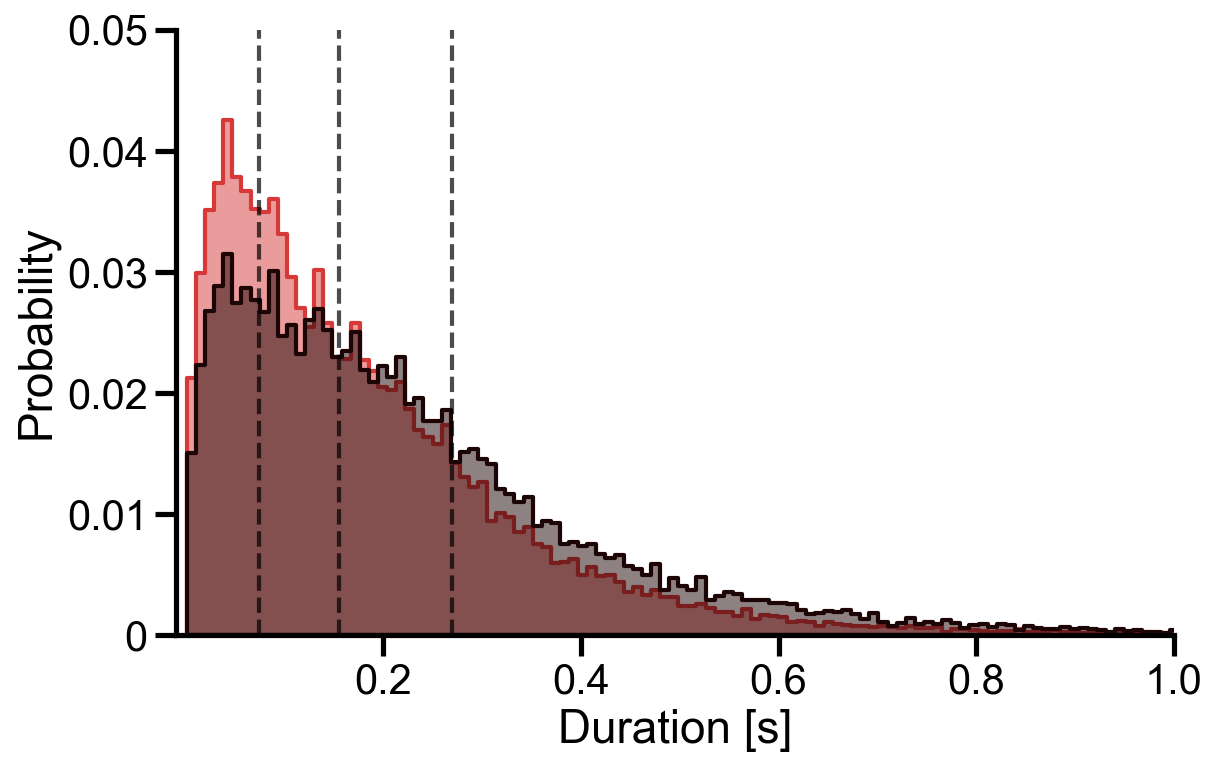

In [ ]:
palette = [CONDITION_PALETTE["pre_ttx"], CONDITION_PALETTE["post_ttx"]]
hist_kw = dict(element='step', stat='probability', common_norm=False,
               fill=True, alpha=0.5, palette=palette, linewidth=2.)

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(data=sweeps, x='duration', hue='condition', **hist_kw,
                ax=ax, legend=False)

ax.set_xlim(-0.01, 1.)
ax.set_ylim(0, 0.05)
ax.set_yticks([0, 0.01, 0.02, 0.03, 0.04, 0.05], labels=['0', '0.01', '0.02', '0.03', '0.04', '0.05'])
ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0], labels=['0.2', '0.4', '0.6', '0.8', '1.0'])
ax.tick_params(axis='both', which='major', labelsize=22, width=2.5, length=10)

# # Quartile reference lines
for x in [all_stats['25%'], all_stats['50%'], all_stats['75%']]:
    ax.axvline(x=x, linewidth=2., linestyle='--', color='black', alpha=0.7)

ax.set_ylabel('Probability', fontsize=22)
ax.set_xlabel('Duration [s]', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20, width=2.5, length=10)

fig.savefig(FIG_OUT / 'nrem_sweep_durations_all_units.pdf', format='pdf', dpi=1200)
fig.savefig(FIG_OUT / 'nrem_sweep_durations_all_units.png', format='png', dpi=300)
plt.show()

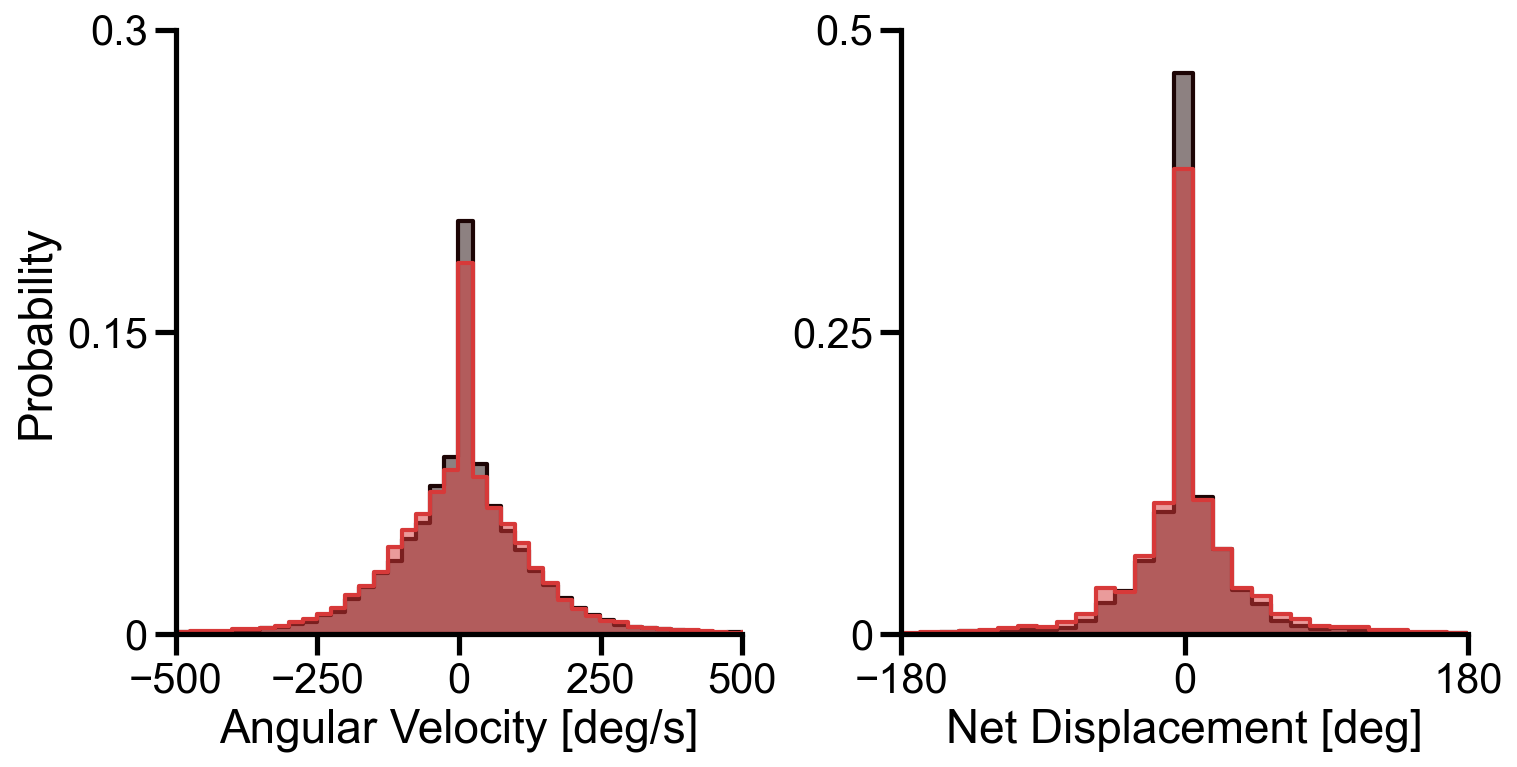

In [6]:
palette = [CONDITION_PALETTE["post_ttx"], CONDITION_PALETTE["pre_ttx"]]
hist_kw = dict(element='step', stat='probability', common_norm=False,
               fill=True, alpha=0.5, palette=palette, linewidth=2., bins=100)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

x_range = 1250
mask = sweeps['velocity'].abs() < x_range
sns.histplot(data=sweeps[mask], x='velocity', hue='condition', **hist_kw, ax=axes[0], legend=False)
axes[0].set_xlim(-500, 500)
axes[0].set_xlabel('Angular Velocity [deg/s]', fontsize=22)
axes[0].set_ylabel('Probability', fontsize=22)
axes[0].set_ylim(0, 0.3)
axes[0].set_yticks([0, 0.15, 0.3], labels=['0', '0.15', '0.3'])
# axes[0].set_xticks([-1000, -500, 0, 500, 1000])
    
x_range = 180
# mask = sweeps['net_displacement'].abs() < 180
sns.histplot(data=sweeps, x='net_displacement', hue='condition', **hist_kw, ax=axes[1], legend=False)
axes[1].set_xlim(-x_range, x_range)
axes[1].set_xlabel('Net Displacement [deg]', fontsize=22)
axes[1].set_ylim(0, 0.5)
axes[1].set_yticks([0, 0.25, 0.5], labels=['0', '0.25', '0.5'])
axes[1].set_xticks([-180, 0, 180])
axes[1].set_ylabel('')


for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=20, width=2.5, length=10)

fig.savefig(FIG_OUT / 'all_units_distributions.pdf', format='pdf', dpi=1200)
plt.show()

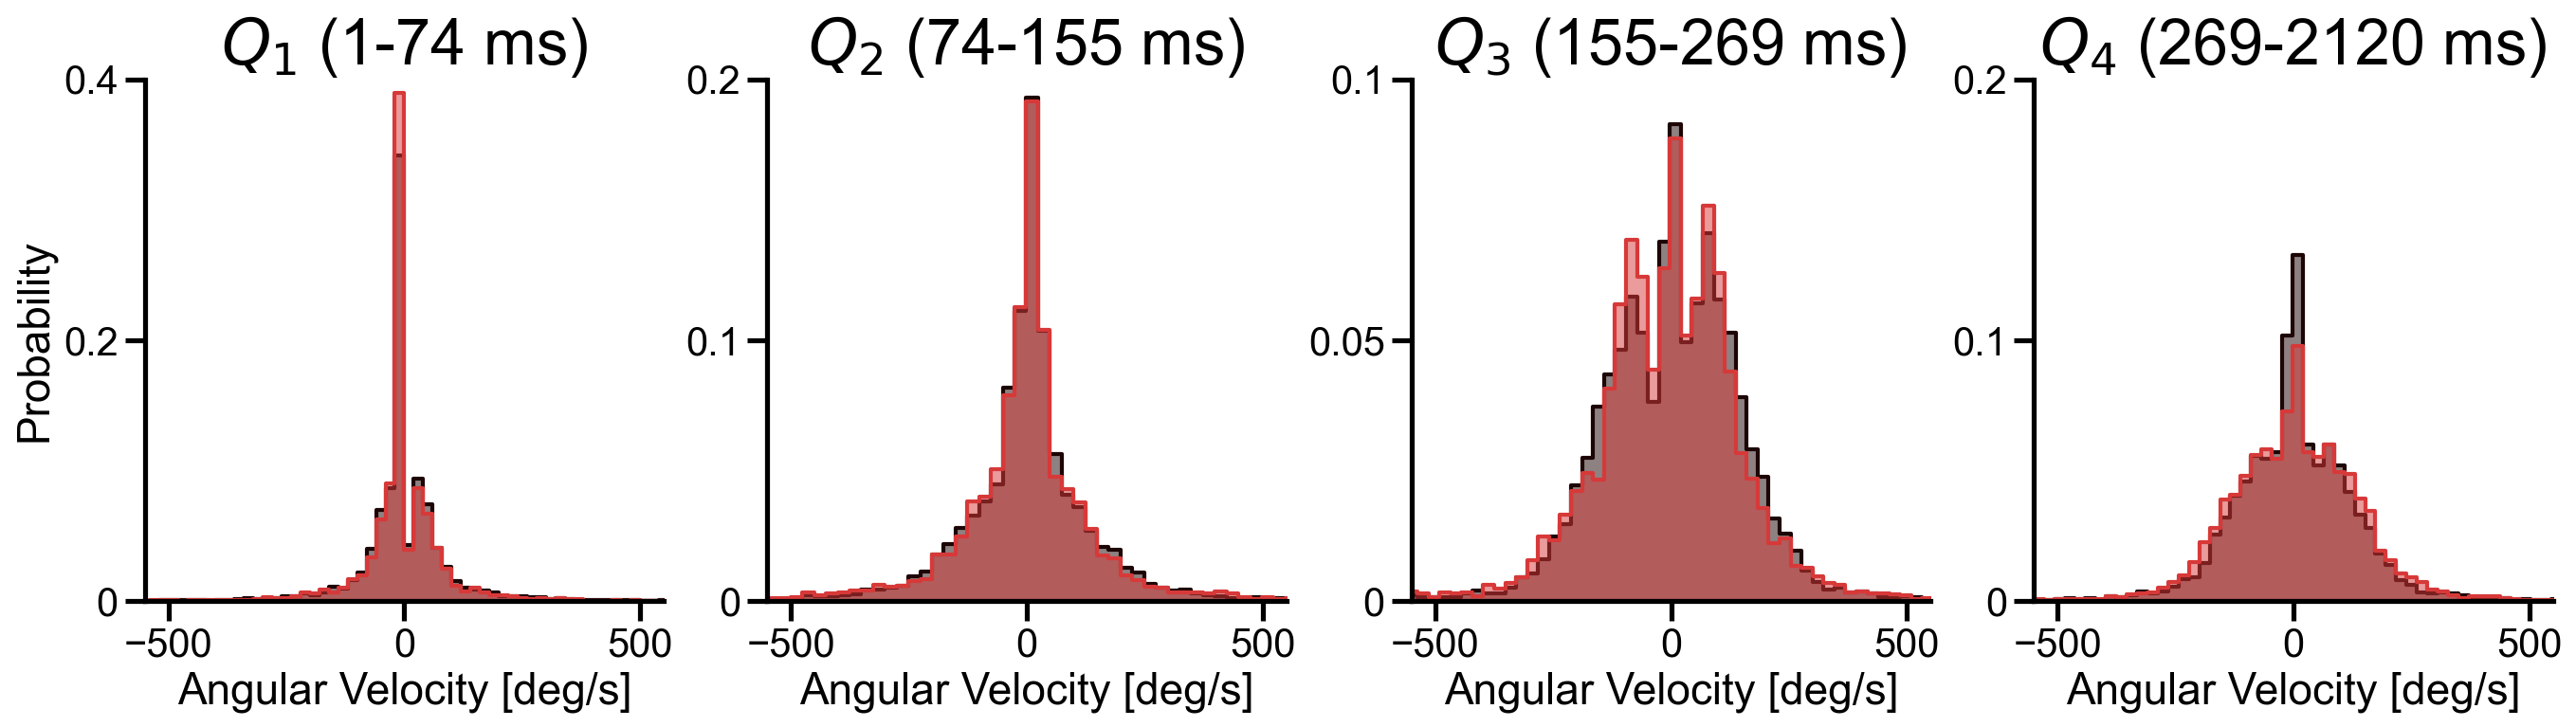

In [210]:
palette = [ CONDITION_PALETTE["post_ttx"], CONDITION_PALETTE["pre_ttx"]]
hist_kw_q = dict(element='step', stat='probability', common_norm=False,
                 fill=True, alpha=0.5, palette=palette, linewidth=2., bins=100)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

q_titles = [
    f'$Q_1$ ({all_stats["min"]*1000:.0f}-{all_stats["25%"]*1000:.0f} ms)',
    f'$Q_2$ ({all_stats["25%"]*1000:.0f}-{all_stats["50%"]*1000:.0f} ms)',
    f'$Q_3$ ({all_stats["50%"]*1000:.0f}-{all_stats["75%"]*1000:.0f} ms)',
    f'$Q_4$ ({all_stats["75%"]*1000:.0f}-{all_stats["max"]*1000:.0f} ms)',
]

# ylims = [(0, 0.4), (0, 0.2), (0, 0.2), (0, 0.1)]

x_range = 1000
for col in range(4):
    ax = axes[col]
    if col == 0:
        qdf = sweeps[sweeps['quartile'] == col]
        mask = qdf['velocity'].abs() < 1000
        sns.histplot(data=qdf[mask], x='velocity', hue='condition', **hist_kw_q,
                    ax=ax, legend=False)
    else:
        qdf = sweeps[sweeps['quartile'] == col]
        mask = qdf['velocity'].abs() < 1250
        sns.histplot(data=qdf[mask], x='velocity', hue='condition', **hist_kw_q,
                    ax=ax, legend=False)
    
    ax.set_xlim(-550, 550)    
    # ax.set_xticks([-400, -200, 0, 200, 400])

    ax.set_title(q_titles[col])
    ax.set_xlabel('Angular Velocity [deg/s]', fontsize=22)
    if col == 0:
        ax.set_ylabel('Probability', fontsize=22)
    else:
        ax.set_ylabel('')

axes[0].set_yticks([0, 0.2, 0.4], labels=['0','0.2', '0.4'])
axes[0].set_ylim(0, 0.4)

axes[1].set_yticks([0, 0.1, 0.2], labels=['0', '0.1', '0.2'])
axes[1].set_ylim(0, 0.2)

axes[2].set_yticks([0, 0.05, 0.1], labels=['0', '0.05', '0.1'])
axes[2].set_ylim(0, 0.1)

axes[3].set_yticks([0, 0.1, 0.2], labels=['0', '0.1', '0.2'])
axes[3].set_ylim(0, 0.2)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=20, width=2.5, length=10)

fig.savefig(FIG_OUT / 'all_units_quartiles2.pdf', format='pdf', dpi=1200)
fig.savefig(FIG_OUT / 'all_units_quartiles2.png', format='png', dpi=300)
plt.show()

### Angular Velocity Distributions

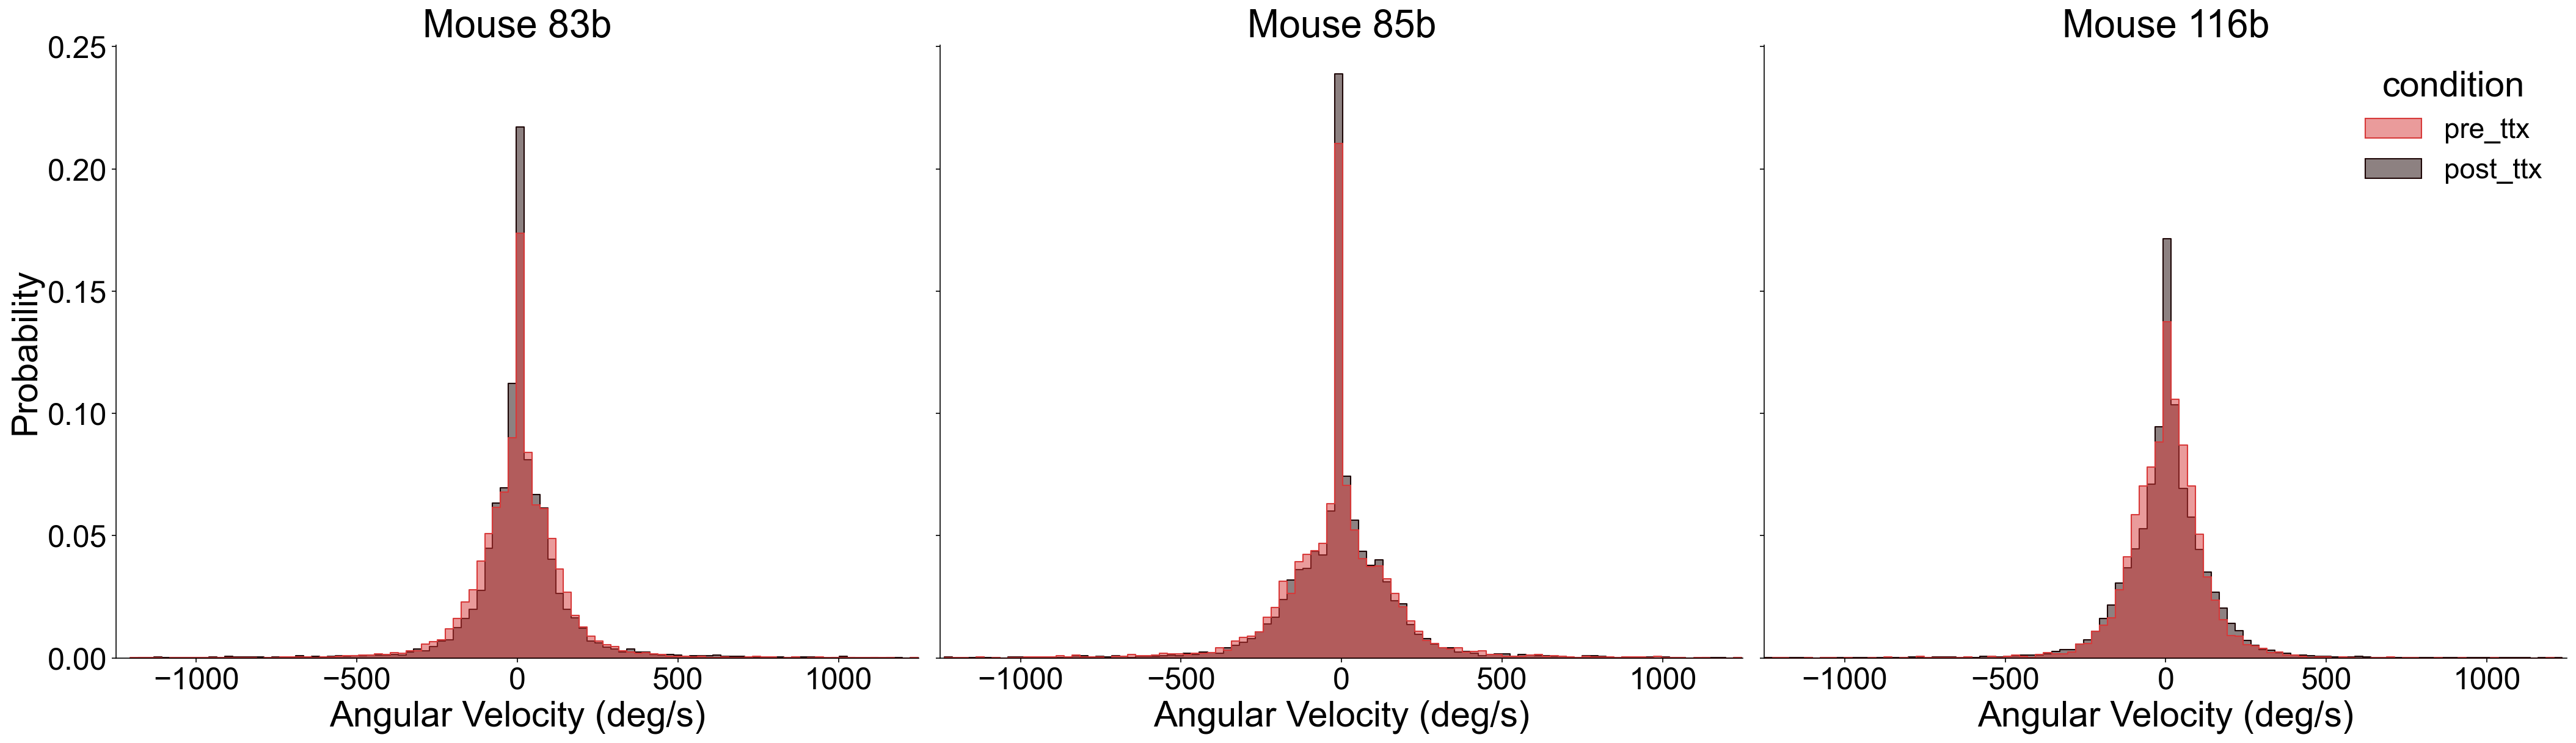

In [6]:
hist_kw_bins = dict(element='step', stat='probability', common_norm=False,
                    fill=True, alpha=0.5, palette=palette, bins=100)

fig, axes = plt.subplots(1, 3, figsize=(28, 8), sharey=True)

for i, unit in enumerate(UNITS):
    udf = sweeps[(sweeps['unit'] == unit) & (sweeps['velocity'].abs() < 1250)]

    sns.histplot(data=udf, x='velocity', hue='condition', **hist_kw_bins,
                 ax=axes[i], legend=(i == 2))
    axes[i].set_xlim(-1250, 1250)
    axes[i].set_title(f'Mouse {unit}')
    axes[i].set_xlabel('Angular Velocity (deg/s)')

    if i == 0:
        axes[i].set_ylabel('Probability')
    else:
        axes[i].set_ylabel('')

fig.savefig(FIG_OUT / 'nrem_velocity_all_units.pdf', format='pdf', dpi=1200)
fig.savefig(FIG_OUT / 'nrem_velocity_all_units.png', format='png', dpi=300)
plt.show()

### Angular Displacement Distributions

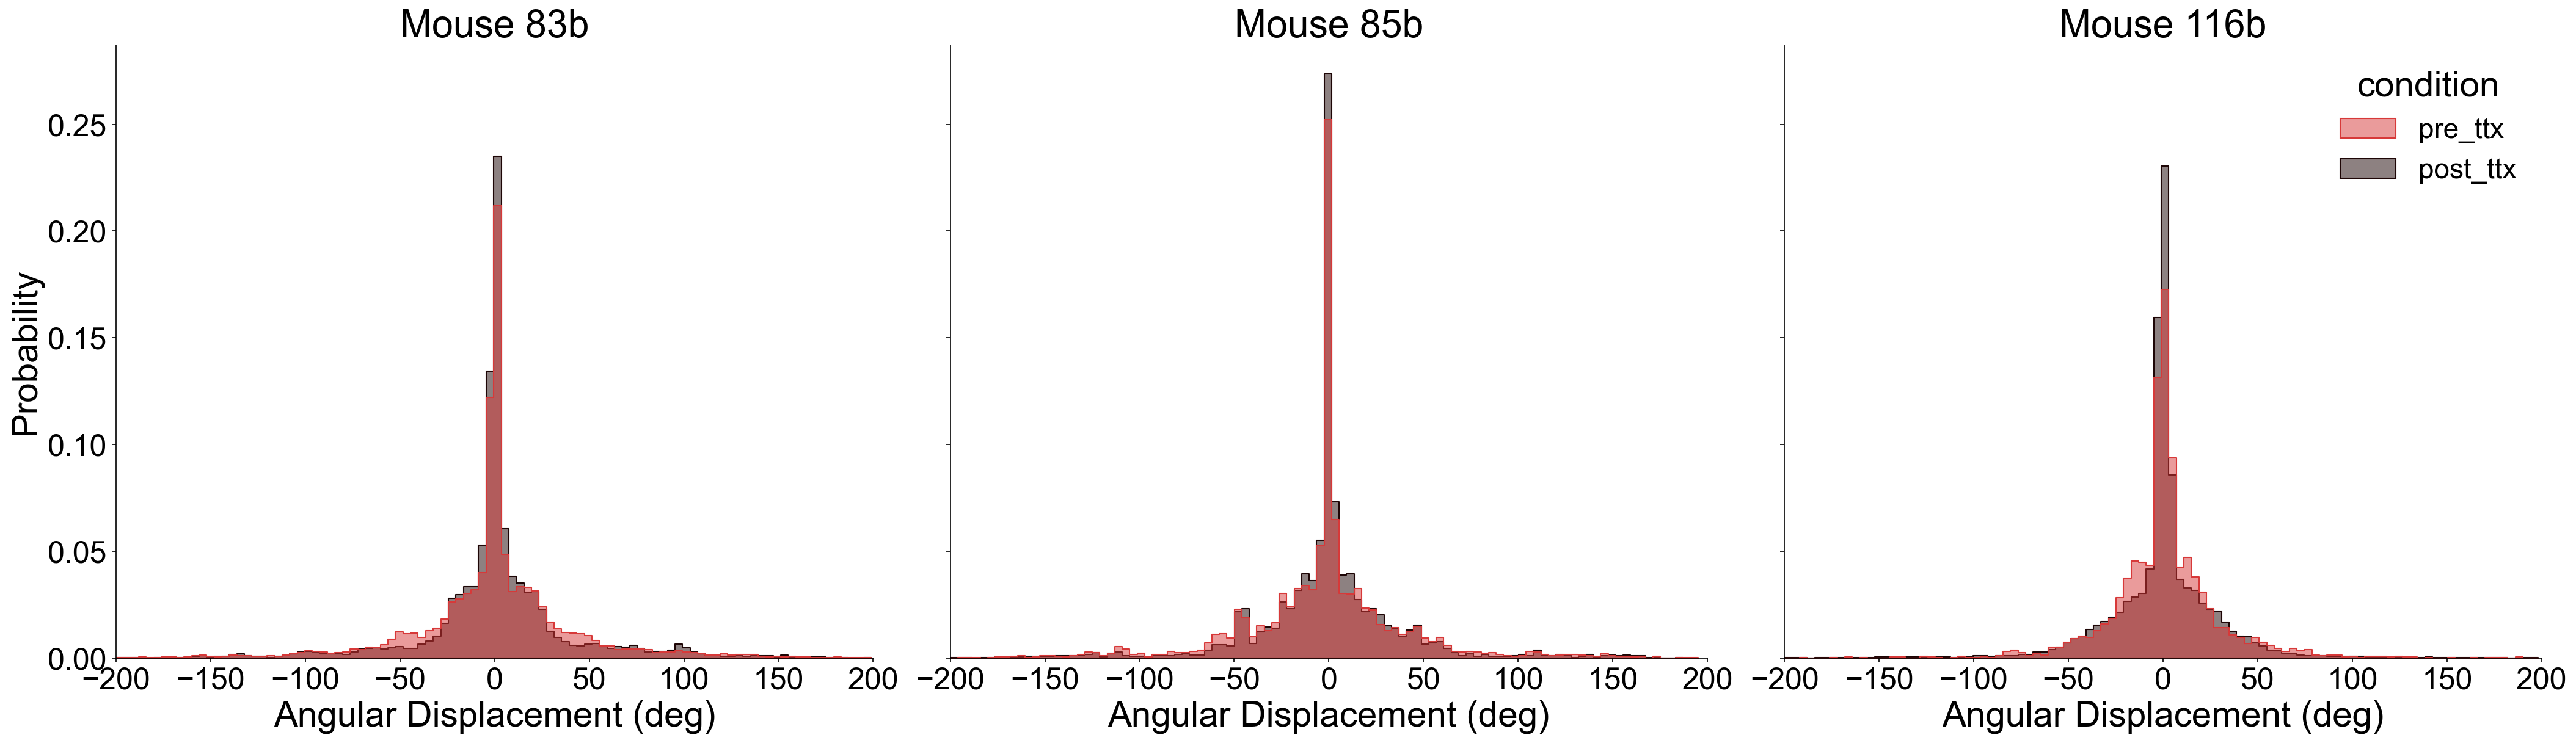

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(28, 8), sharey=True)

for i, unit in enumerate(UNITS):
    udf = sweeps[(sweeps['unit'] == unit) & (sweeps['net_displacement'].abs() < 200)]

    sns.histplot(data=udf, x='net_displacement', hue='condition', **hist_kw_bins,
                 ax=axes[i], legend=(i == 2))
    axes[i].set_xlim(-200, 200)
    axes[i].set_title(f'Mouse {unit}')
    axes[i].set_xlabel('Angular Displacement (deg)')

    if i == 0:
        axes[i].set_ylabel('Probability')
    else:
        axes[i].set_ylabel('')

fig.savefig(FIG_OUT / 'nrem_displacement_all_units.pdf', format='pdf', dpi=1200)
fig.savefig(FIG_OUT / 'nrem_displacement_all_units.png', format='png', dpi=300)
plt.show()

### Angular Velocity by Duration Quartile (per Unit)

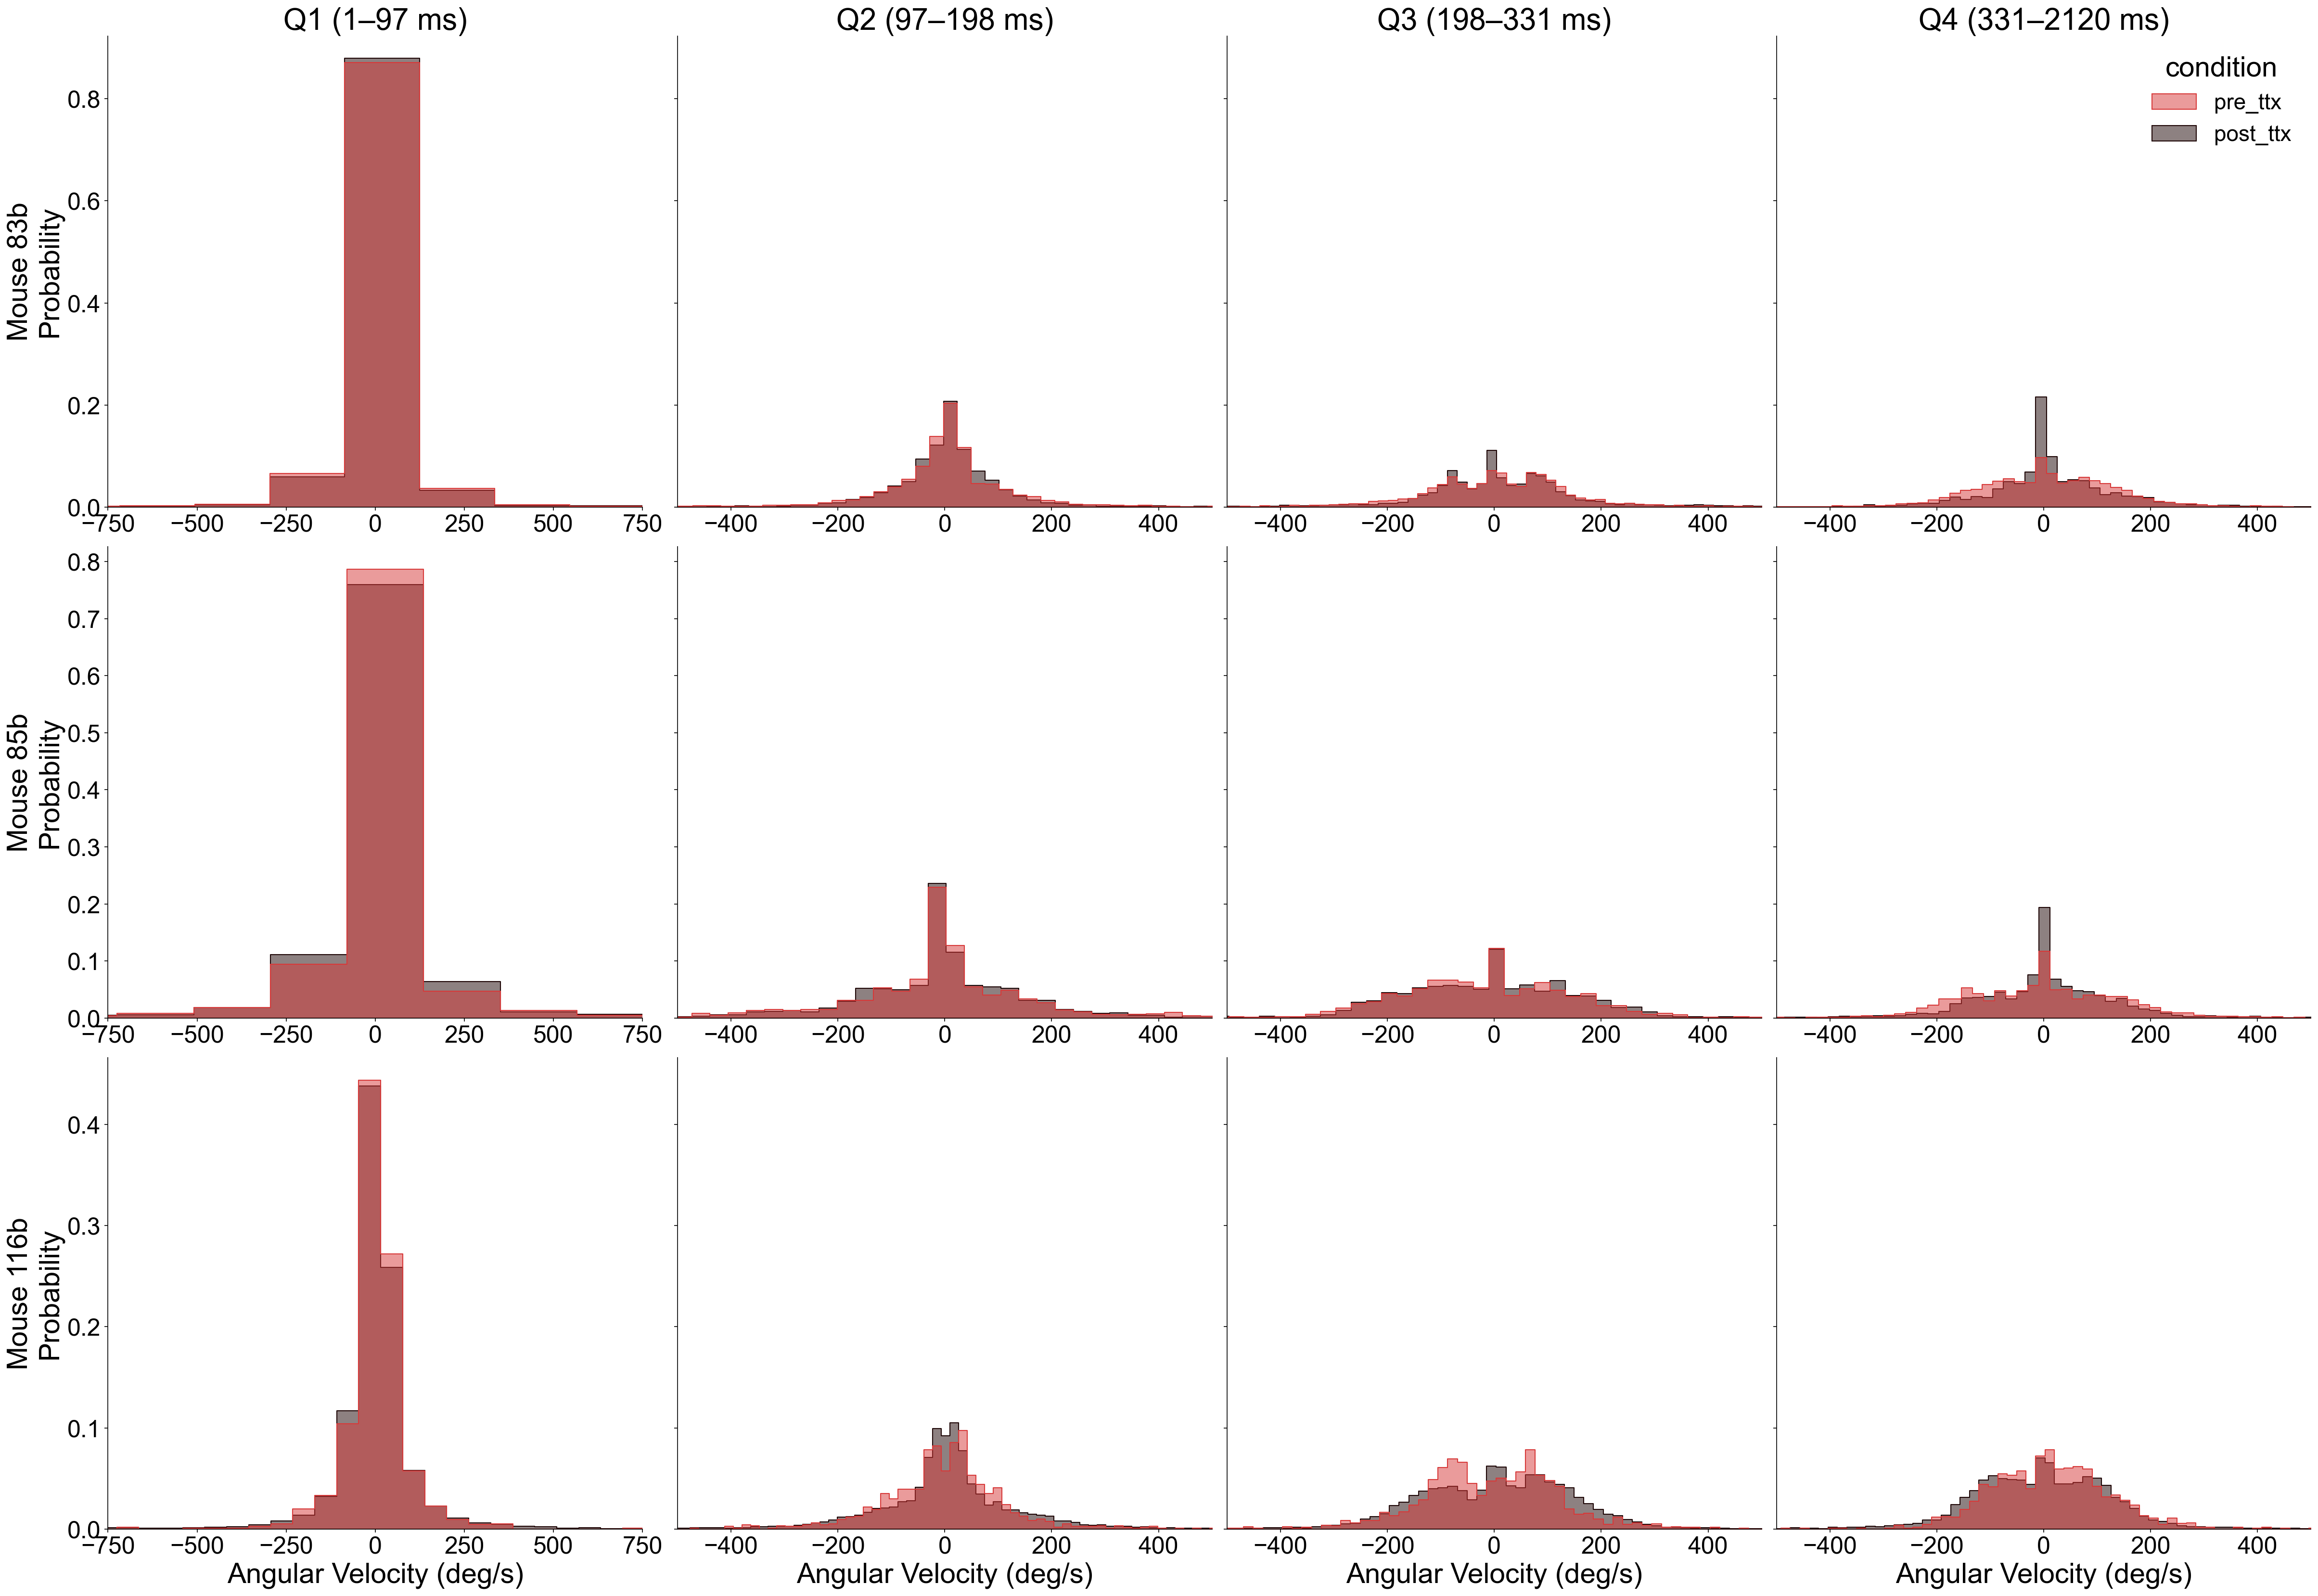

In [8]:
hist_kw_q = dict(element='step', stat='probability', common_norm=False,
                 fill=True, alpha=0.5, palette=palette)

fig, axes = plt.subplots(3, 4, figsize=(32, 22), sharey='row')

xlims = [(-750, 750), (-500, 500), (-500, 500), (-500, 500)]

for row, unit in enumerate(UNITS):
    udf = sweeps[sweeps['unit'] == unit]
    st = unit_stats[unit]

    for col in range(4):
        ax = axes[row, col]
        qdf = udf[udf['quartile'] == col]

        sns.histplot(data=qdf, x='velocity', hue='condition', **hist_kw_q,
                     ax=ax, legend=(row == 0 and col == 3))
        ax.set_xlim(xlims[col])

        # Column titles on top row
        if row == 0:
            q_bounds = {
                0: f'Q1 ({st["min"]*1000:.0f}–{st["25%"]*1000:.0f} ms)',
                1: f'Q2 ({st["25%"]*1000:.0f}–{st["50%"]*1000:.0f} ms)',
                2: f'Q3 ({st["50%"]*1000:.0f}–{st["75%"]*1000:.0f} ms)',
                3: f'Q4 ({st["75%"]*1000:.0f}–{st["max"]*1000:.0f} ms)',
            }
            ax.set_title(q_bounds[col])

        # Row label on leftmost column
        if col == 0:
            ax.set_ylabel(f'Mouse {unit}\nProbability')
        else:
            ax.set_ylabel('')

        # x-label only on bottom row
        if row == 2:
            ax.set_xlabel('Angular Velocity (deg/s)')
        else:
            ax.set_xlabel('')

fig.savefig(FIG_OUT / 'nrem_velocity_quartiles_all_units.pdf', format='pdf', dpi=1200)
fig.savefig(FIG_OUT / 'nrem_velocity_quartiles_all_units.png', format='png', dpi=300)
plt.show()

### Summary Violin Plots — Duration, Velocity, Displacement

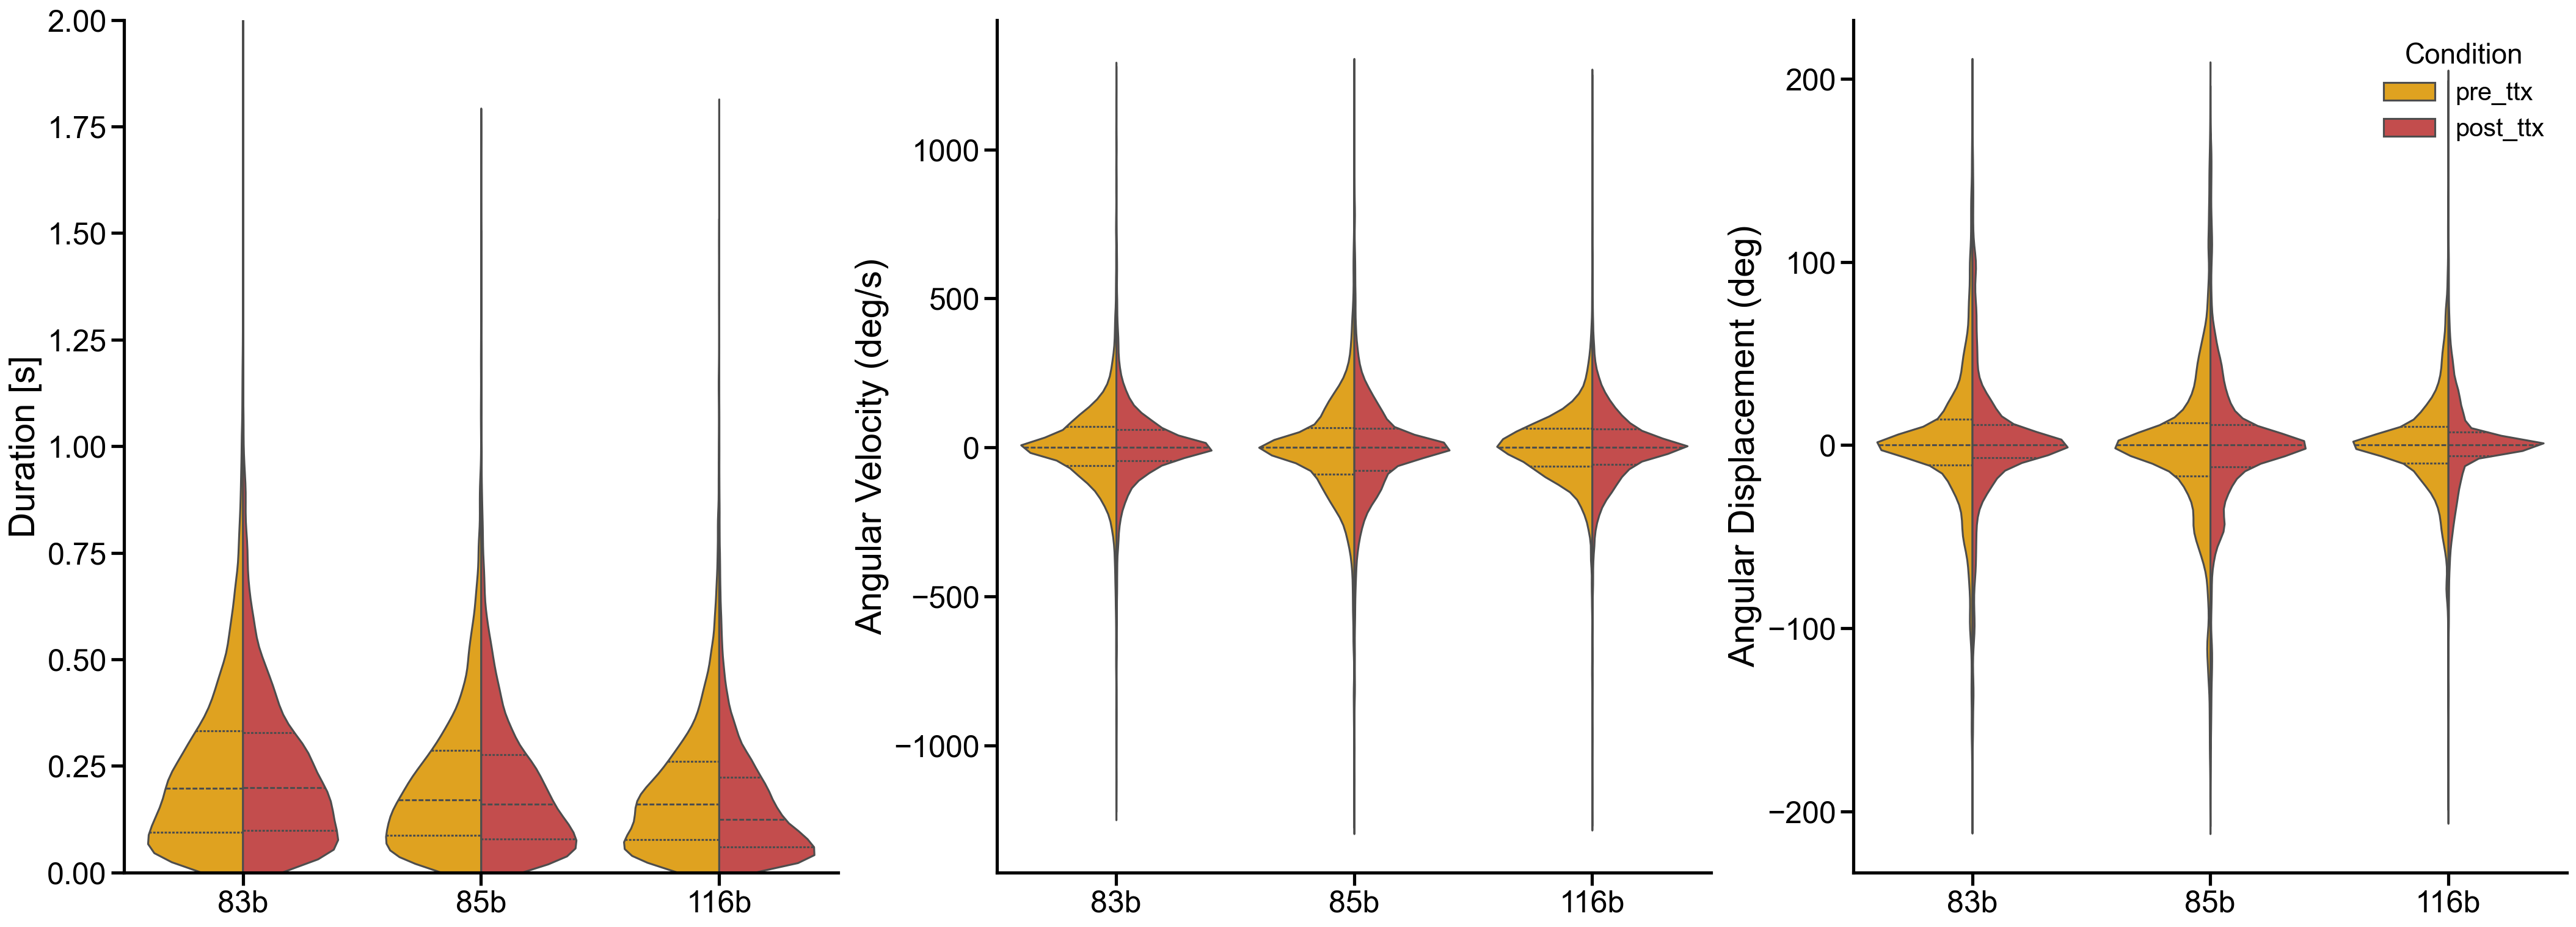

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(28, 10))
CONDITION_PALETTE = {"pre_ttx": "#ffae00", "post_ttx": "#d73939"}

violin_kw = dict(x='unit', hue='condition', palette=CONDITION_PALETTE,
                 split=True, inner='quart', linewidth=1.5,
                 order=UNITS, hue_order=CONDITION_ORDER, density_norm='width')

# Duration
sns.violinplot(data=sweeps, y='duration', **violin_kw, ax=axes[0], legend=False)
axes[0].set_ylabel('Duration [s]')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 2)

# Velocity
sns.violinplot(data=sweeps[sweeps['velocity'].abs() < 1250],
               y='velocity', **violin_kw, ax=axes[1], legend=False)
axes[1].set_ylabel('Angular Velocity (deg/s)')
axes[1].set_xlabel('')

# Displacement
sns.violinplot(data=sweeps[sweeps['net_displacement'].abs() < 200],
               y='net_displacement', **violin_kw, ax=axes[2])
axes[2].set_ylabel('Angular Displacement (deg)')
axes[2].set_xlabel('')

# Move legend outside
axes[2].legend(title='Condition', loc='upper right', fontsize=20, title_fontsize=22)

fig.savefig(FIG_OUT / 'nrem_summary_violins_all_units.pdf', format='pdf', dpi=1200)
fig.savefig(FIG_OUT / 'nrem_summary_violins_all_units.png', format='png', dpi=300)
plt.show()